# Deriving insights about matrix multiplication using parallel processors

In [1]:
import benchmark
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt

We have already defined the necessary function to perform matrix multiplication using nested loops, numpy and parallel processing in "serial.py", "optimized.py" and "parallel.py" respectively. Then, we can use "benchmark.py" to call those methods on some randomly generated matrices, calculate runtime and speedup and compare the corresponding times. We will use the method "run_experiment" in "benchmark.py" with 3 values for the size of the matrix of increasing size.

In [2]:
df1 = benchmark.run_experiment(50)
print("experiment 1 done")
df2 = benchmark.run_experiment(200)
print("experiment 2 done")
df3 = benchmark.run_experiment(600)
print("experiment 3 done")

experiment 1 done
experiment 2 done
experiment 3 done


Then, we can have a look into what the datasets looks like by printing each one of them. This will display the serial, optimized and parallel times for all possible number of parallel prcessors for the 3 different matrix sizes defined above.

In [3]:
print(df1)
print(f"Maximum number of processors is {len(df1['size'])}")


   size  t_serial  t_optimized  t_parallel
0     2   0.09011     0.000089    0.357544
1     4   0.09011     0.000089    0.392401
2     8   0.09011     0.000089    0.543104
3    12   0.09011     0.000089    0.850926
Maximum number of processors is 4


In [4]:
print(df2)

   size  t_serial  t_optimized  t_parallel
0     2  5.828406     0.003956    0.472771
1     4  5.828406     0.003956    0.547483
2     8  5.828406     0.003956    0.652990
3    12  5.828406     0.003956    0.864907


In [5]:
print(df3)

   size    t_serial  t_optimized  t_parallel
0     2  151.181209     0.101171    4.293978
1     4  151.181209     0.101171    4.285386
2     8  151.181209     0.101171    4.583660
3    12  151.181209     0.101171    4.893171


After extracting the data, we wish to plot speedup and runtime as a function of the number of processors used where speedup is equal to the runtime with the serial implementation divided by the runtime with the parallel one. To do that, we will use the custom method plot_compare defined in "benchmark.py" for each one of the DataFrames above.

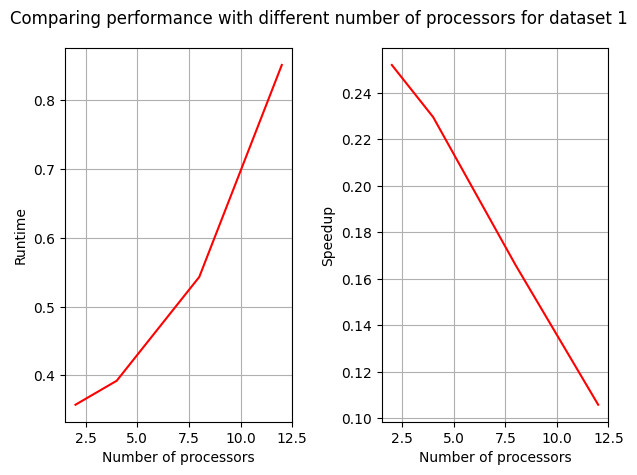

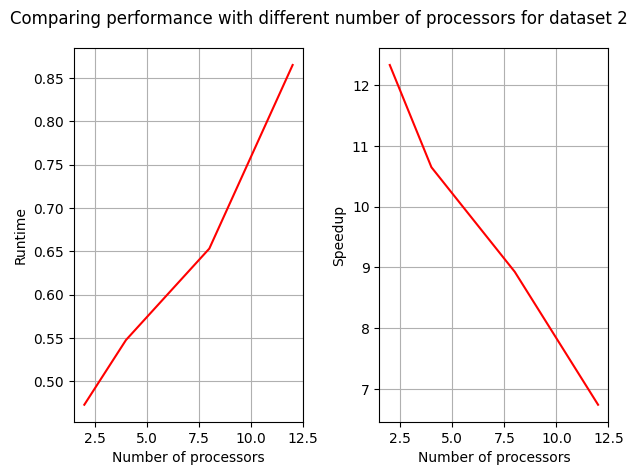

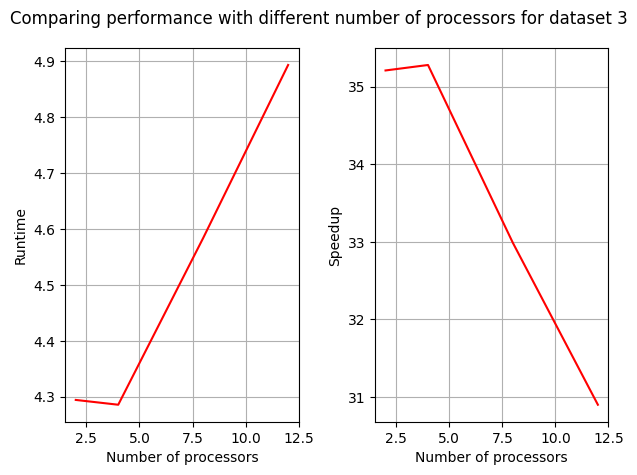

In [6]:
benchmark.plot_compare(df1, 1)
benchmark.plot_compare(df2, 2)
benchmark.plot_compare(df3, 3)

What we expect to see is that as the number of processors increases the time taken to run the matrix multiplication drops and speedup rises, as it is inversely proportional to that time. However, the results we got difer based on the size of the random matrix. As we can see, there is no significant advantage to adding parallel processors in the 1st case as speedup drops. However, in the 2nd case it is advantageous to introduce approximately up to 7 parallel processors, while in the 3rd case the more processors we use the faster we get the results we want. In reality, parallel processing is truly beneficial only if the amount of data that needs to be processed is very large, meaning if the matrix size is very large. This is because speedup isn't perfect, due to overhead, which is the memory space required to store data other than the values themselves. In this case, overhead consists of the communication between the many processors through pipes, queues or other structures, slowing the computation down. Hence, parallel processing is prefered when the process is computationally expensive enough to compensate for the memory overhead introduced.

In [7]:
print(f"Time with numpy is {df1["t_optimized"][0]}")

Time with numpy is 8.930000331019983e-05


Finally, notice that the numpy implementation is better than the custom parallelized version no matter how many parallel processors we used, since it uses multiple techniques to speed up computations. This is because it performs vectorization using C, which is much faster than Python. Also, numpy arrays occupy contiguous blocks of memory, which is much more efficient than traditional python lists or arrays. Finally, it introduces fixed data types, further reducing memory overhead.